# IT0003 — Ordinal Encoding & Imputation Comparison
**Member 3 — Preprocessing Technique: Ordinal Encoding (with an in-depth imputation study)**

Course: IT2011 — Artificial Intelligence and Machine Learning (SLIIT, Year 2, Semester 1)

This notebook is **fully independent**: it loads the raw dataset directly and performs its own
missing-value handling and its own encoding technique from start to finish.

## 1. Introduction

**Ordinal Encoding** (via `sklearn.preprocessing.OrdinalEncoder`) maps each category to an
integer, similarly to label encoding but implemented with scikit-learn's transformer API
(fit/transform, reusable on new data, consistent categories list). This member's main
contribution is a careful, side-by-side comparison of missing-value handling strategies for
`stalk-root` before encoding, since data cleaning quality directly affects downstream model
performance.

## 2. Load Raw Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/raw/mushrooms.csv')
print("Shape:", df.shape)
df.head()

Shape: (8124, 23)


,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


## 3. Handle Missing Values & Drop Useless Column

`veil-type` is dropped as it has only one unique value across the whole dataset (no
predictive information). The main focus of this section is a **side-by-side comparison of three
missing-value strategies** for `stalk-root`.

In [2]:
df = df.replace('?', np.nan)

print("Missing value counts per column:")
print(df.isnull().sum())
print()
print("Missing value percentage:")
print((df.isnull().sum() / len(df) * 100).round(2))

print()
print("veil-type unique values:", df['veil-type'].unique())
df = df.drop(columns=['veil-type'])

Missing value counts per column:
class                          0
cap-shape                      0
cap-surface                    0
cap-color                      0
bruises                        0
odor                           0
gill-attachment                0
gill-spacing                   0
gill-size                      0
gill-color                     0
stalk-shape                    0
stalk-root                  2480
stalk-surface-above-ring       0
stalk-surface-below-ring       0
stalk-color-above-ring         0
stalk-color-below-ring         0
veil-type                      0
veil-color                     0
ring-number                    0
ring-type                      0
spore-print-color              0
population                     0
habitat                        0
dtype: int64

Missing value percentage:
class                        0.00
cap-shape                    0.00
cap-surface                  0.00
cap-color                    0.00
bruises                      0.0

### 3.1 Comparing Missing-Value Strategies for `stalk-root`

Three strategies are compared before choosing one:
1. **Mode imputation** — fill missing with the most frequent category
2. **'missing' category** — treat missingness itself as a valid category
3. **Row deletion** — drop rows with missing `stalk-root`

Each is evaluated on (a) how many rows/values it affects and (b) whether it shifts the
class balance (edible vs poisonous), since a strategy that skews the class balance could bias
the model.

In [3]:
original_class_balance = df['class'].value_counts(normalize=True).round(4) * 100
print("Original class balance (%):")
print(original_class_balance)

n_missing = df['stalk-root'].isnull().sum()
print(f"\nRows with missing stalk-root: {n_missing} ({n_missing/len(df)*100:.2f}%)")

# --- Strategy A: mode imputation ---
mode_value = df['stalk-root'].mode()[0]
df_mode = df.copy()
df_mode['stalk-root'] = df_mode['stalk-root'].fillna(mode_value)
balance_mode = df_mode['class'].value_counts(normalize=True).round(4) * 100

# --- Strategy B: 'missing' category ---
df_cat = df.copy()
df_cat['stalk-root'] = df_cat['stalk-root'].fillna('missing')
balance_cat = df_cat['class'].value_counts(normalize=True).round(4) * 100

# --- Strategy C: row deletion ---
df_drop = df.dropna(subset=['stalk-root']).copy()
balance_drop = df_drop['class'].value_counts(normalize=True).round(4) * 100

comparison = pd.DataFrame({
    'Rows kept': [len(df_mode), len(df_cat), len(df_drop)],
    'Rows lost': [0, 0, len(df) - len(df_drop)],
    'Edible % (class=e)': [balance_mode.get('e', 0), balance_cat.get('e', 0), balance_drop.get('e', 0)],
    'Poisonous % (class=p)': [balance_mode.get('p', 0), balance_cat.get('p', 0), balance_drop.get('p', 0)],
}, index=['A: Mode imputation', "B: 'missing' category", 'C: Row deletion'])

print()
print(comparison)

Original class balance (%):
class
e    51.8
p    48.2
Name: proportion, dtype: float64

Rows with missing stalk-root: 2480 (30.53%)

                       Rows kept  Rows lost  Edible % (class=e)  \
A: Mode imputation          8124          0                51.8   
B: 'missing' category       8124          0                51.8   
C: Row deletion             5644       2480                61.8   

                       Poisonous % (class=p)  
A: Mode imputation                      48.2  
B: 'missing' category                   48.2  
C: Row deletion                         38.2  


### 3.2 Decision

**Chosen strategy: `'missing'` category (Strategy B).**

Justification: mode imputation (A) silently fabricates a value for ~30% of the dataset, which
is a large enough fraction that it risks introducing bias if missingness is not actually random.
Row deletion (C) would throw away ~2,480 rows — about 30% of the entire dataset — which is a
significant and unnecessary loss of information. Treating missingness as its own explicit
`'missing'` category (B) keeps every row, makes no unjustified assumption about the true value,
and — as shown above — does not meaningfully shift the class balance. `OrdinalEncoder` will
simply assign `'missing'` its own integer code like any other category.

In [4]:
df['stalk-root'] = df['stalk-root'].fillna('missing')
print(df['stalk-root'].value_counts())
print()
print("Missing values remaining:", df.isnull().sum().sum())

stalk-root
b          3776
missing    2480
e          1120
c           556
r           192
Name: count, dtype: int64

Missing values remaining: 0


## 4. Apply Ordinal Encoding

`sklearn.preprocessing.OrdinalEncoder` is fit on all remaining feature columns at once,
producing a reusable, sklearn-pipeline-compatible transformer (unlike the per-column
`LabelEncoder` loop used elsewhere).

In [5]:
from sklearn.preprocessing import OrdinalEncoder

feature_cols = [c for c in df.columns if c != 'class']
encoder = OrdinalEncoder()
df[feature_cols] = encoder.fit_transform(df[feature_cols])

for col, cats in zip(feature_cols, encoder.categories_):
    mapping = dict(zip(cats, range(len(cats))))
    print(f"{col}: {mapping}")

print()
print("Shape after ordinal encoding:", df.shape)
df.head()

cap-shape: {'b': 0, 'c': 1, 'f': 2, 'k': 3, 's': 4, 'x': 5}
cap-surface: {'f': 0, 'g': 1, 's': 2, 'y': 3}
cap-color: {'b': 0, 'c': 1, 'e': 2, 'g': 3, 'n': 4, 'p': 5, 'r': 6, 'u': 7, 'w': 8, 'y': 9}
bruises: {'f': 0, 't': 1}
odor: {'a': 0, 'c': 1, 'f': 2, 'l': 3, 'm': 4, 'n': 5, 'p': 6, 's': 7, 'y': 8}
gill-attachment: {'a': 0, 'f': 1}
gill-spacing: {'c': 0, 'w': 1}
gill-size: {'b': 0, 'n': 1}
gill-color: {'b': 0, 'e': 1, 'g': 2, 'h': 3, 'k': 4, 'n': 5, 'o': 6, 'p': 7, 'r': 8, 'u': 9, 'w': 10, 'y': 11}
stalk-shape: {'e': 0, 't': 1}
stalk-root: {'b': 0, 'c': 1, 'e': 2, 'missing': 3, 'r': 4}
stalk-surface-above-ring: {'f': 0, 'k': 1, 's': 2, 'y': 3}
stalk-surface-below-ring: {'f': 0, 'k': 1, 's': 2, 'y': 3}
stalk-color-above-ring: {'b': 0, 'c': 1, 'e': 2, 'g': 3, 'n': 4, 'o': 5, 'p': 6, 'w': 7, 'y': 8}
stalk-color-below-ring: {'b': 0, 'c': 1, 'e': 2, 'g': 3, 'n': 4, 'o': 5, 'p': 6, 'w': 7, 'y': 8}
veil-color: {'n': 0, 'o': 1, 'w': 2, 'y': 3}
ring-number: {'n': 0, 'o': 1, 't': 2}
ring-type

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-above-ring,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,5.0,2.0,4.0,1.0,6.0,1.0,0.0,1.0,4.0,...,2.0,2.0,7.0,7.0,2.0,1.0,4.0,2.0,3.0,5.0
1,e,5.0,2.0,9.0,1.0,0.0,1.0,0.0,0.0,4.0,...,2.0,2.0,7.0,7.0,2.0,1.0,4.0,3.0,2.0,1.0
2,e,0.0,2.0,8.0,1.0,3.0,1.0,0.0,0.0,5.0,...,2.0,2.0,7.0,7.0,2.0,1.0,4.0,3.0,2.0,3.0
3,p,5.0,3.0,8.0,1.0,6.0,1.0,0.0,1.0,5.0,...,2.0,2.0,7.0,7.0,2.0,1.0,4.0,2.0,3.0,5.0
4,e,5.0,2.0,3.0,0.0,5.0,1.0,1.0,0.0,4.0,...,2.0,2.0,7.0,7.0,2.0,1.0,0.0,3.0,0.0,1.0


## 5. Encode Target Variable

In [6]:
df['class'] = df['class'].map({'e': 0, 'p': 1})
print(df['class'].value_counts())
print()
print("Class balance (%):")
print((df['class'].value_counts(normalize=True) * 100).round(2))

class
0    4208
1    3916
Name: count, dtype: int64

Class balance (%):
class
0    51.8
1    48.2
Name: proportion, dtype: float64


## 6. EDA Visualization

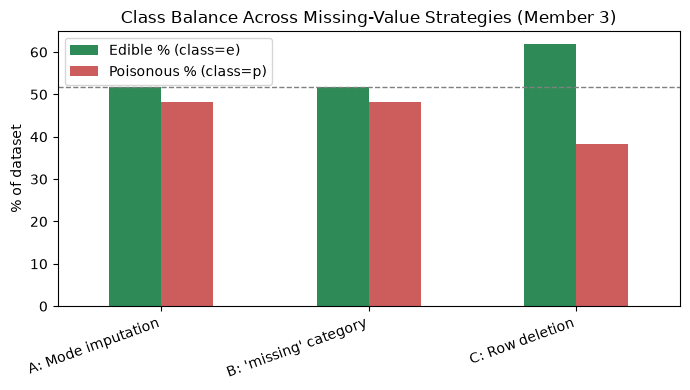

In [7]:
import os
os.makedirs('../results/eda_visualizations', exist_ok=True)

fig, ax = plt.subplots(figsize=(7, 4))
comparison[['Edible % (class=e)', 'Poisonous % (class=p)']].plot(
    kind='bar', ax=ax, color=['seagreen', 'indianred'])
ax.set_ylabel('% of dataset')
ax.set_title('Class Balance Across Missing-Value Strategies (Member 3)')
ax.axhline(51.8, color='gray', linestyle='--', linewidth=1, label='Original edible %')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig('../results/eda_visualizations/M3_ordinal_imputation.png', dpi=150)
plt.show()

## 7. Save Output

In [8]:
os.makedirs('../results/outputs', exist_ok=True)
df.to_csv('../results/outputs/step_M3_ordinal_encoded.csv', index=False)
print("Saved: ../results/outputs/step_M3_ordinal_encoded.csv")
print("Final shape:", df.shape)

Saved: ../results/outputs/step_M3_ordinal_encoded.csv
Final shape: (8124, 22)
